# M2.Ex1: Advertising Revenue

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M2/exercises/ex1_multi-reg.ipynb)

In [9]:
import pandas as pd
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Advertising Dataset

The Advertising Dataset is a fundamental resource in statistical learning and regression analysis. It is primarily known for its use in the first chapter of the seminal textbook "An Introduction to Statistical Learning" (ISLR) by Gareth James, Daniela Witten, Trevor Hastie, and Robert Tibshirani.

The dataset is used to illustrate the relationship between advertising budgets across different media and the resulting product sales.

- Features: `3` numerical
- Target: `sales` of the product (in thousands of units).
- Size: `200` samples.
- Source: [Advertising Dataset](https://www.statlearning.com/s/Advertising.csv)

### Step 1. Load the data

In [15]:
df = pd.read_csv("https://www.statlearning.com/s/Advertising.csv", index_col=0)
df

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
...,...,...,...,...
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5


### Step 2.a Assign variables `X` to the features and `y` to the target

In [16]:
df = df.rename(columns={'radio': 'Radio', 'newspaper': 'Newspaper', 'sales': 'Sales'})

X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

### Step 2.b print the type of each

In [17]:
print("Type of X:", type(X))
print("Type of y:", type(y))

Type of X: <class 'pandas.DataFrame'>
Type of y: <class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [18]:
print("Target dtype:", y.dtype)
print()
print("The target (Sales) is NUMERICAL — it represents continuous units sold.")
print("Therefore, the task is REGRESSION, not classification.")

Target dtype: float64

The target (Sales) is NUMERICAL — it represents continuous units sold.
Therefore, the task is REGRESSION, not classification.


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [19]:
print("X shape:", X.shape)     
print("y shape:", y.shape)     
print()
print(f"Samples : {X.shape[0]}")
print(f"Features: {X.shape[1]}")

X shape: (200, 3)
y shape: (200,)

Samples : 200
Features: 3


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [20]:
stats = df.agg(['min', 'max', 'median', 'mean', 'std'])
stats

,TV,Radio,Newspaper,Sales
min,0.700000,0.000000,0.300000,1.600000
max,296.400000,49.600000,114.000000,27.000000
median,149.750000,22.900000,25.750000,12.900000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457


### Step 5. How much difference do you see in the scale of each feature? (calculate the featre-wise range differences)

In [21]:
range_diff = X.max() - X.min()
print("Feature-wise range (max - min):")
print(range_diff)
print()
print("TV has the largest range (~293), Newspaper is mid (~196), Radio is smallest (~49).")
print("This scale difference motivates StandardScaler in the pipeline.")

Feature-wise range (max - min):
TV           295.7
Radio         49.6
Newspaper    113.7
dtype: float64

TV has the largest range (~293), Newspaper is mid (~196), Radio is smallest (~49).
This scale difference motivates StandardScaler in the pipeline.


### Step 6.a Plot each of the features vs the target

Hint use this: `sns.pairplot()`

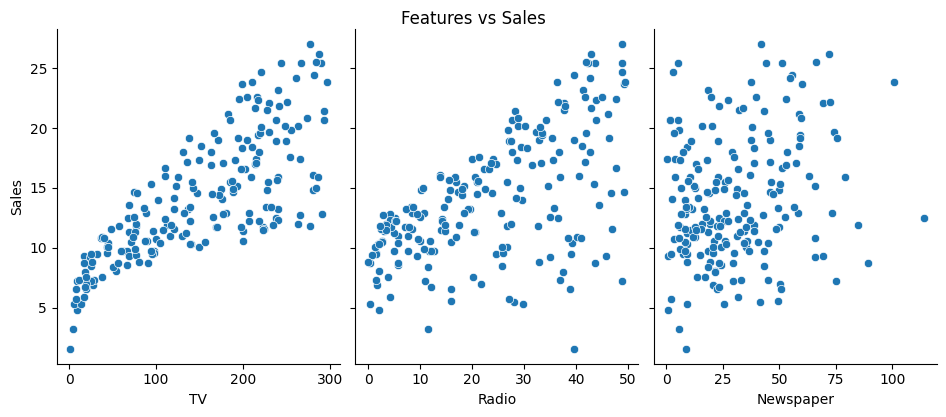

In [22]:
sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars=['Sales'], height=4, aspect=0.8)
plt.suptitle('Features vs Sales', y=1.02)
plt.show()

### Step 6.b What is the relationship between the feature and the target? (increasing or decreasing or none)

1. `x=TV` and `y=Sales`
2. `x=Radio` and `y=Sales`
3. `x=Newspaper` and `y=Sales`

In [23]:
print("1. TV vs Sales      → INCREASING (strong positive linear relationship)")
print("2. Radio vs Sales   → INCREASING (moderate positive relationship)")
print("3. Newspaper vs Sales → NONE / very weak (no clear linear trend)")

1. TV vs Sales      → INCREASING (strong positive linear relationship)
2. Radio vs Sales   → INCREASING (moderate positive relationship)
3. Newspaper vs Sales → NONE / very weak (no clear linear trend)


### Step 7. Define the pipeline with pre-processing steps

Make a Pipeline of three sequential steps:

1. transformer: `SimpleImputer` (to fill in missing values)
2. transformer: `StandardScaler` (to scale numerical features)
3. predictor: `LinearRegression` (to model the relationship)

In [24]:
from sklearn.pipeline import Pipeline
preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
])

predictor = LinearRegression()




In [25]:
pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", predictor),
    ]
)

### Step 8. Split the dataset into train and test sets

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (160, 3)
X_test : (40, 3)


### Step 9.a Fit the pipeline on the training set

In [27]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str

### Step 9.b Identify the learned coefficients (for each feature) and the bias term

In [ ]:
lr = pipe.named_steps['regressor']
scaler = pipe.named_steps['preprocessor'].named_steps['scaler']

coef_scaled = lr.coef_
coef_original = coef_scaled / scaler.scale_

print("Coefficients (scaled space):")
for name, coef in zip(X.columns, coef_scaled):
    print(f"  {name:12s}: {coef:.4f}")

print()
print("Coefficients (original units — sales units per $1,000 spend):")
for name, coef in zip(X.columns, coef_original):
    print(f"  {name:12s}: {coef:.4f}")

print()
print(f"Bias (intercept): {lr.intercept_:.4f}")

Coefficients (scaled space):
  TV          : 3.7642
  Radio       : 2.7923
  Newspaper   : 0.0560

Coefficients (original units — sales units per $1,000 spend):
  TV          : 0.0447
  Radio       : 0.1892
  Newspaper   : 0.0028

Bias (intercept): 14.1000


### Step 9.c how much spending on TV `$1,000` more, factor into Sales?

In [ ]:

tv_coef_original = (lr.coef_[0] / scaler.scale_[0])
print(f"Each additional $1,000 on TV → Sales change by {tv_coef_original:.4f} thousand units")

Each additional $1,000 on TV → Sales change by 0.0447 thousand units


### Step 9.d if we take `$5,000` away from Newspaper and put it in Radio how much difference does that make into Sales?

In [31]:
radio_coef     = lr.coef_[1] / scaler.scale_[1]
newspaper_coef = lr.coef_[2] / scaler.scale_[2]

delta = 5 * radio_coef - 5 * newspaper_coef 
print(f"Radio coef     : {radio_coef:.4f}")
print(f"Newspaper coef : {newspaper_coef:.4f}")
print()
print(f"Shifting $5,000 from Newspaper → Radio changes Sales by {delta:+.4f} thousand units")

Radio coef     : 0.1892
Newspaper coef : 0.0028

Shifting $5,000 from Newspaper → Radio changes Sales by +0.9322 thousand units


### Step 9.e if we spend nothing at all on advertising, how much do we estimate our Sales to be?

In [32]:
import numpy as np

zero_spend = pd.DataFrame([[0, 0, 0]], columns=['TV', 'Radio', 'Newspaper'])
predicted_sales = pipe.predict(zero_spend)[0]
print(f"Estimated Sales with zero advertising: {predicted_sales:.2f} thousand units")
print()
print("Note: the intercept represents the model's baseline prediction,")
print("but zero-spend is outside the training distribution, so interpret with caution.")

Estimated Sales with zero advertising: 2.98 thousand units

Note: the intercept represents the model's baseline prediction,
but zero-spend is outside the training distribution, so interpret with caution.


### Step 10. Evaluate the pipeline on the test set

In [33]:
score = pipe.score(X_test, y_test)
print(f"Pipeline R² on test set: {score:.4f}")

Pipeline R² on test set: 0.8994


### Step 11. Define a `LinearRegression` model without the pre-processing steps, and compare it's score with the pipeline. Which one is better?